# Project 1: Customer Churn Prediction for Subscription Services

## 🎯 Project Goal
The objective of this project is to predict whether a customer will churn (cancel the service) based on their demographic and account information. 
Retaining existing customers is significantly more cost-effective than acquiring new ones. By identifying at-risk customers early, companies can take proactive measures to improve retention.

## 📊 Dataset
**Source:** Telco Customer Churn dataset (Kaggle).
**Target Variable:** `Churn` (Yes/No).
**Key Features:**
- **Demographics:** Gender, SeniorCitizen, Partner, Dependents.
- **Services:** PhoneService, InternetService, OnlineSecurity, etc.
- **Account Info:** Tenure, Contract, PaymentMethod, MonthlyCharges, TotalCharges.

## 1. Setup and Data Loading
Importing necessary libraries (Pandas, NumPy, Matplotlib, Seaborn) and loading the dataset from the `data/raw` directory.

In [64]:
import pandas as pd
import os

# Data path
file_path = "../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv"

# Read the data
df = pd.read_csv(file_path)

## 2. Data Understanding
Inspecting the dataframe structure to understand the data types, checking for missing values, and getting a statistical summary.
- **Shape:** How many rows (customers) and columns (features)?
- **Data Types:** Do columns match their content (e.g., is `TotalCharges` numeric)?
- **Missing Values:** Are there nulls to handle?

In [65]:
# Inspecting the first 5 rows of the dataframe
df.head()

# Inspecting the dataframe info
print("\nDataframe Info:")
df.info()


Dataframe Info:
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   st

In [66]:
# Inspecting the dataframe shape
print("\nDataframe Shape:", df.shape)

# Inspecting the dataframe data types
print("\nDataframe Data Types:\n", df.dtypes)

# Inspecting for missing values
print("\nMissing Values in Each Column:\n", df.isnull().sum())
print("\nTotal Missing Values in Dataframe:", df.isnull().sum().sum())


Dataframe Shape: (7043, 21)

Dataframe Data Types:
 customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

Missing Values in Each Column:
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
Stre

## 3. Data Cleaning
Preparing the data for analysis by fixing data types and removing irrelevant features.
- **Convert `TotalCharges`:** Parsing the column to numeric values and handling errors.
- **Handle Nulls:** Removing rows with missing values generated during conversion.
- **Drop `customerID`:** Removing the unique identifier column as it offers no predictive value.

In [67]:
# Converting 'TotalCharges' to numeric values
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print("\nDataframe Info After Conversion:")
df.info()


Dataframe Info After Conversion:
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7

In [68]:
# Checking for missing values after conversion
print("\nMissing Values in TotalCharges Column:", df['TotalCharges'].isnull().sum())


Missing Values in TotalCharges Column: 11


In [69]:
# Removing the rows with missing 'TotalCharges' values. Since there are only 11 such rows, this should be acceptable.
df = df[df['TotalCharges'].notna()]

In [70]:
# Checking for missing values after removal
print("\nMissing Values in TotalCharges Column After Removal:\n", df['TotalCharges'].isnull().sum())


Missing Values in TotalCharges Column After Removal:
 0


In [71]:
# Dropping 'customerID' column as it is not useful for analysis
df = df.drop(columns=['customerID'])

## 4. Exploratory Data Analysis (EDA)
Visualizing the data to understand patterns, correlations, and the distribution of the target variable.
- **Target Distribution:** analyzing the imbalance between Churn vs. No-Churn.
- **Numerical Features:** Visualizing distributions of `Tenure`, `MonthlyCharges` relative to Churn.
- **Categorical Features:** Analyzing churn rates across different categories like `Contract`, `PaymentMethod`, and `InternetService`.

In [72]:
# Checking the target distribution visually using graphical representation
print("\nChurn Value Counts:\n", df['Churn'].value_counts())


Churn Value Counts:
 Churn
No     5163
Yes    1869
Name: count, dtype: int64


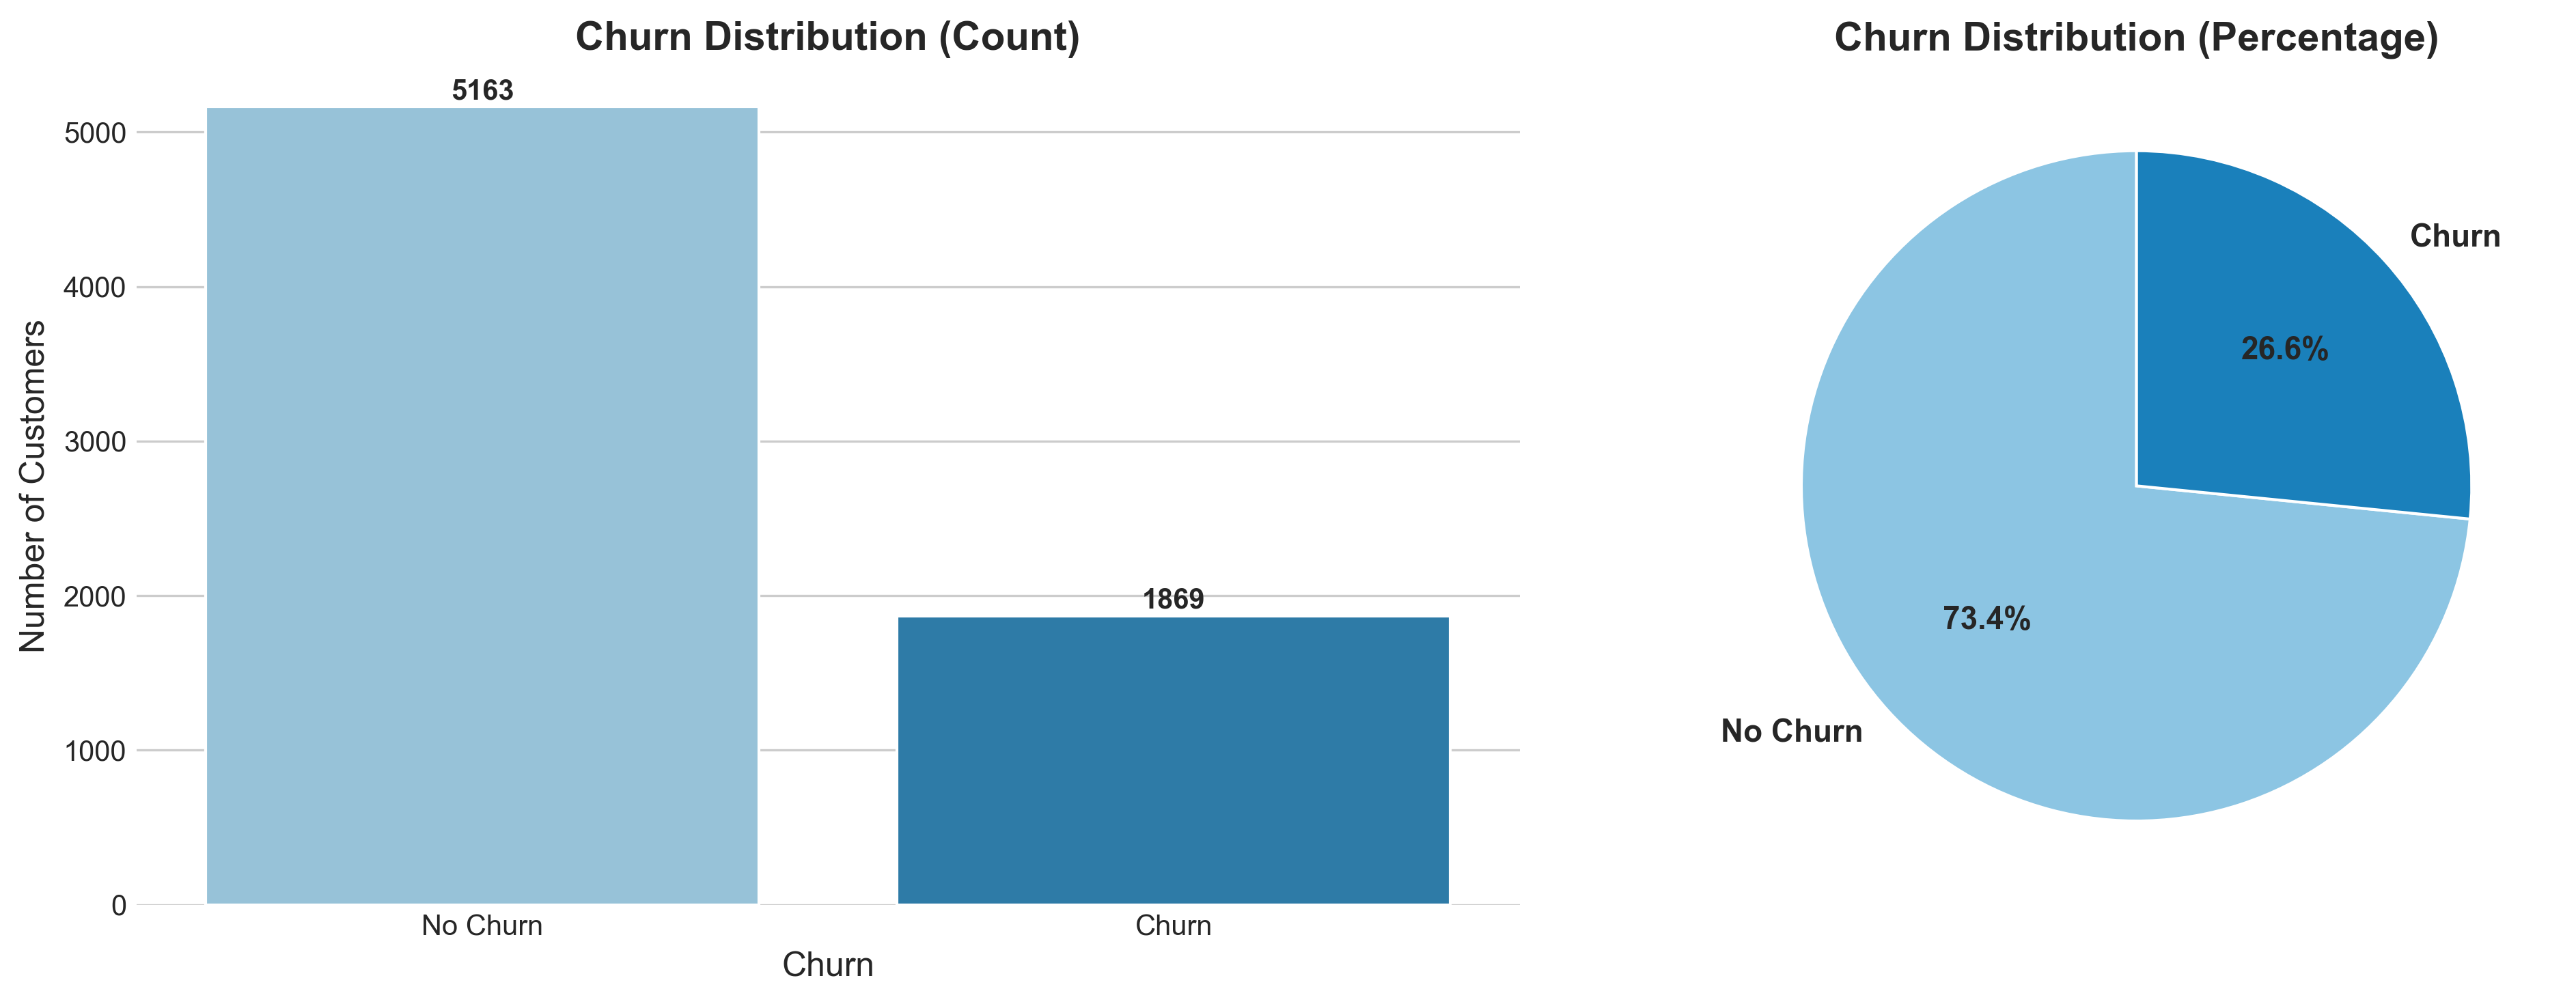


CHURN DISTRIBUTION SUMMARY

Total Customers: 7032
No Churn: 5163 (73.42%)
Churn: 1869 (26.58%)
Churn Ratio: 1 churned customer per 3 customers


In [73]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings  

# Set style for better-looking plots
sns.set_style("whitegrid")

# Create a figure with two subplots (high DPI for better resolution)
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=300)

# 1. Bar chart for churn distribution
churn_counts = df['Churn'].value_counts()
colors = ["#8cc5e3", "#1a80bb"]  # Lightblue for No, Blue for Yes
sns.barplot(x=churn_counts.index, y=churn_counts.values, ax=axes[0], palette=colors)
axes[0].set_title('Churn Distribution (Count)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Churn', fontsize=12)
axes[0].set_ylabel('Number of Customers', fontsize=12)
axes[0].set_xticklabels(['No Churn', 'Churn'])

# Add value labels on bars
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# 2. Pie chart for churn distribution (percentage)
churn_percentage = df['Churn'].value_counts(normalize=True) * 100
labels = ['No Churn', 'Churn']
axes[1].pie(churn_percentage.values, labels=labels, autopct='%1.1f%%', 
            colors=colors, startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'})
axes[1].set_title('Churn Distribution (Percentage)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*50)
print("CHURN DISTRIBUTION SUMMARY")
print("="*50)
print(f"\nTotal Customers: {len(df)}")
print(f"No Churn: {churn_counts['No']} ({churn_percentage['No']:.2f}%)")
print(f"Churn: {churn_counts['Yes']} ({churn_percentage['Yes']:.2f}%)")
print(f"Churn Ratio: 1 churned customer per {len(df) // churn_counts['Yes']} customers")
print("="*50)

# Suppress warnings for cleaner output
warnings.simplefilter('ignore')

### 4.1. Numerical Features Analysis
We examine the distribution of numerical features relative to churn.
- **Tenure (Months):** Do new customers (low tenure) leave more frequently than long-standing ones?
- **Monthly Charges:** Are customers paying higher monthly fees more likely to leave?

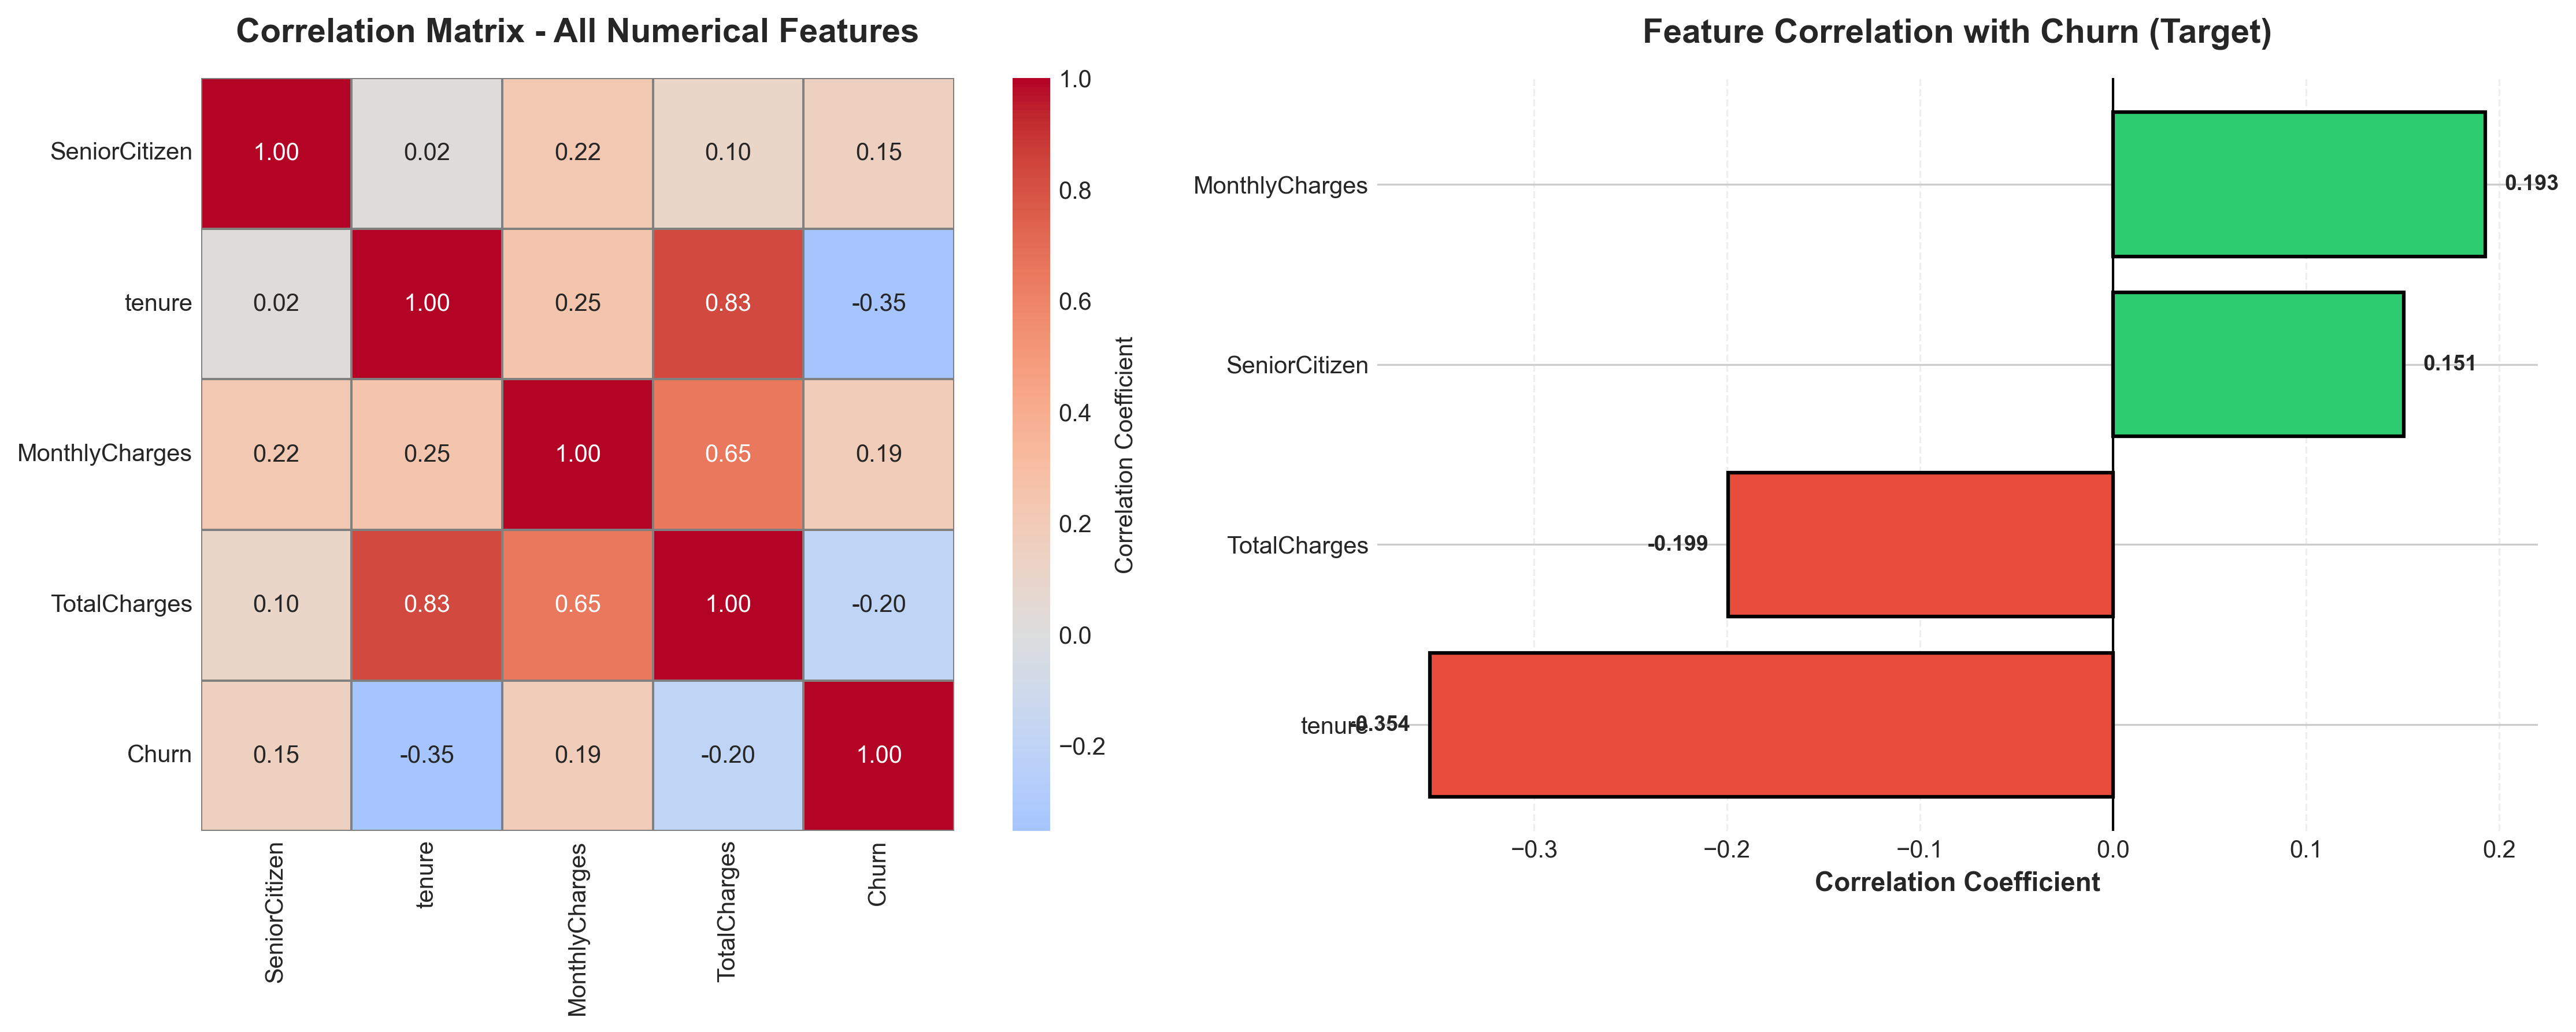


██████████████████████████████████████████████████████████████████████
█                   FEATURE CORRELATION WITH CHURN                   █
██████████████████████████████████████████████████████████████████████

Correlation Ranking (sorted by absolute value):

 1. tenure               | Correlation: -0.3540 (↓ Negative)
 2. TotalCharges         | Correlation: -0.1995 (↓ Negative)
 3. MonthlyCharges       | Correlation:  0.1929 (↑ Positive)
 4. SeniorCitizen        | Correlation:  0.1505 (↑ Positive)

██████████████████████████████████████████████████████████████████████
📊 Interpretation:
   • Positive correlation: Feature increases → Churn likelihood increases
   • Negative correlation: Feature increases → Churn likelihood decreases
██████████████████████████████████████████████████████████████████████



In [74]:
# Prepare data for correlation analysis
# Create a copy of the dataframe and convert categorical 'Churn' to binary
df_corr = df.copy()
df_corr['Churn'] = df_corr['Churn'].map({'Yes': 1, 'No': 0})

# Select only numerical columns for correlation
numerical_cols = df_corr.select_dtypes(include=['int64', 'float64']).columns
df_numerical = df_corr[numerical_cols]

# Calculate correlation with Churn
churn_correlation = df_numerical.corr()['Churn'].sort_values(ascending=False)

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=300)

# 1. Correlation heatmap for numerical features
corr_matrix = df_numerical.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, ax=axes[0], cbar_kws={'label': 'Correlation Coefficient'},
            linewidths=0.5, linecolor='gray')
axes[0].set_title('Correlation Matrix - All Numerical Features', fontsize=14, fontweight='bold', pad=15)

# 2. Bar chart of correlations with Churn (excluding Churn itself)
churn_corr_sorted = churn_correlation.drop('Churn').sort_values()
colors_corr = ['#e74c3c' if x < 0 else '#2ecc71' for x in churn_corr_sorted.values]
axes[1].barh(range(len(churn_corr_sorted)), churn_corr_sorted.values, color=colors_corr, edgecolor='black', linewidth=1.5)
axes[1].set_yticks(range(len(churn_corr_sorted)))
axes[1].set_yticklabels(churn_corr_sorted.index, fontsize=10)
axes[1].set_xlabel('Correlation Coefficient', fontsize=11, fontweight='bold')
axes[1].set_title('Feature Correlation with Churn (Target)', fontsize=14, fontweight='bold', pad=15)
axes[1].axvline(x=0, color='black', linestyle='-', linewidth=1)
axes[1].grid(axis='x', alpha=0.3, linestyle='--')
axes[1].set_axisbelow(True)

# Add value labels on bars
for i, v in enumerate(churn_corr_sorted.values):
    axes[1].text(v + 0.01 if v > 0 else v - 0.01, i, f'{v:.3f}', 
                va='center', ha='left' if v > 0 else 'right', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

# Print correlation summary
print("\n" + "█"*70)
print("█" + " FEATURE CORRELATION WITH CHURN ".center(68) + "█")
print("█"*70)
print("\nCorrelation Ranking (sorted by absolute value):\n")
churn_corr_abs = churn_correlation.drop('Churn').abs().sort_values(ascending=False)
for i, (feature, corr_val) in enumerate(churn_corr_abs.items(), 1):
    original_corr = churn_correlation[feature]
    direction = "↑ Positive" if original_corr > 0 else "↓ Negative"
    print(f"{i:2d}. {feature:20s} | Correlation: {original_corr:7.4f} ({direction})")

print("\n" + "█"*70)
print("📊 Interpretation:")
print("   • Positive correlation: Feature increases → Churn likelihood increases")
print("   • Negative correlation: Feature increases → Churn likelihood decreases")
print("█"*70 + "\n")

### 4.2. Categorical Features Analysis
We analyze how different categories affect the churn rate.
- **Contract Type:** Do customers with month-to-month contracts churn more often than those with one/two-year contracts?
- **Payment Method:** Is there a specific payment method (e.g., Electronic check) associated with higher churn?
- **Internet Service:** Does the type of internet service (Fiber optic vs. DSL) impact retention?

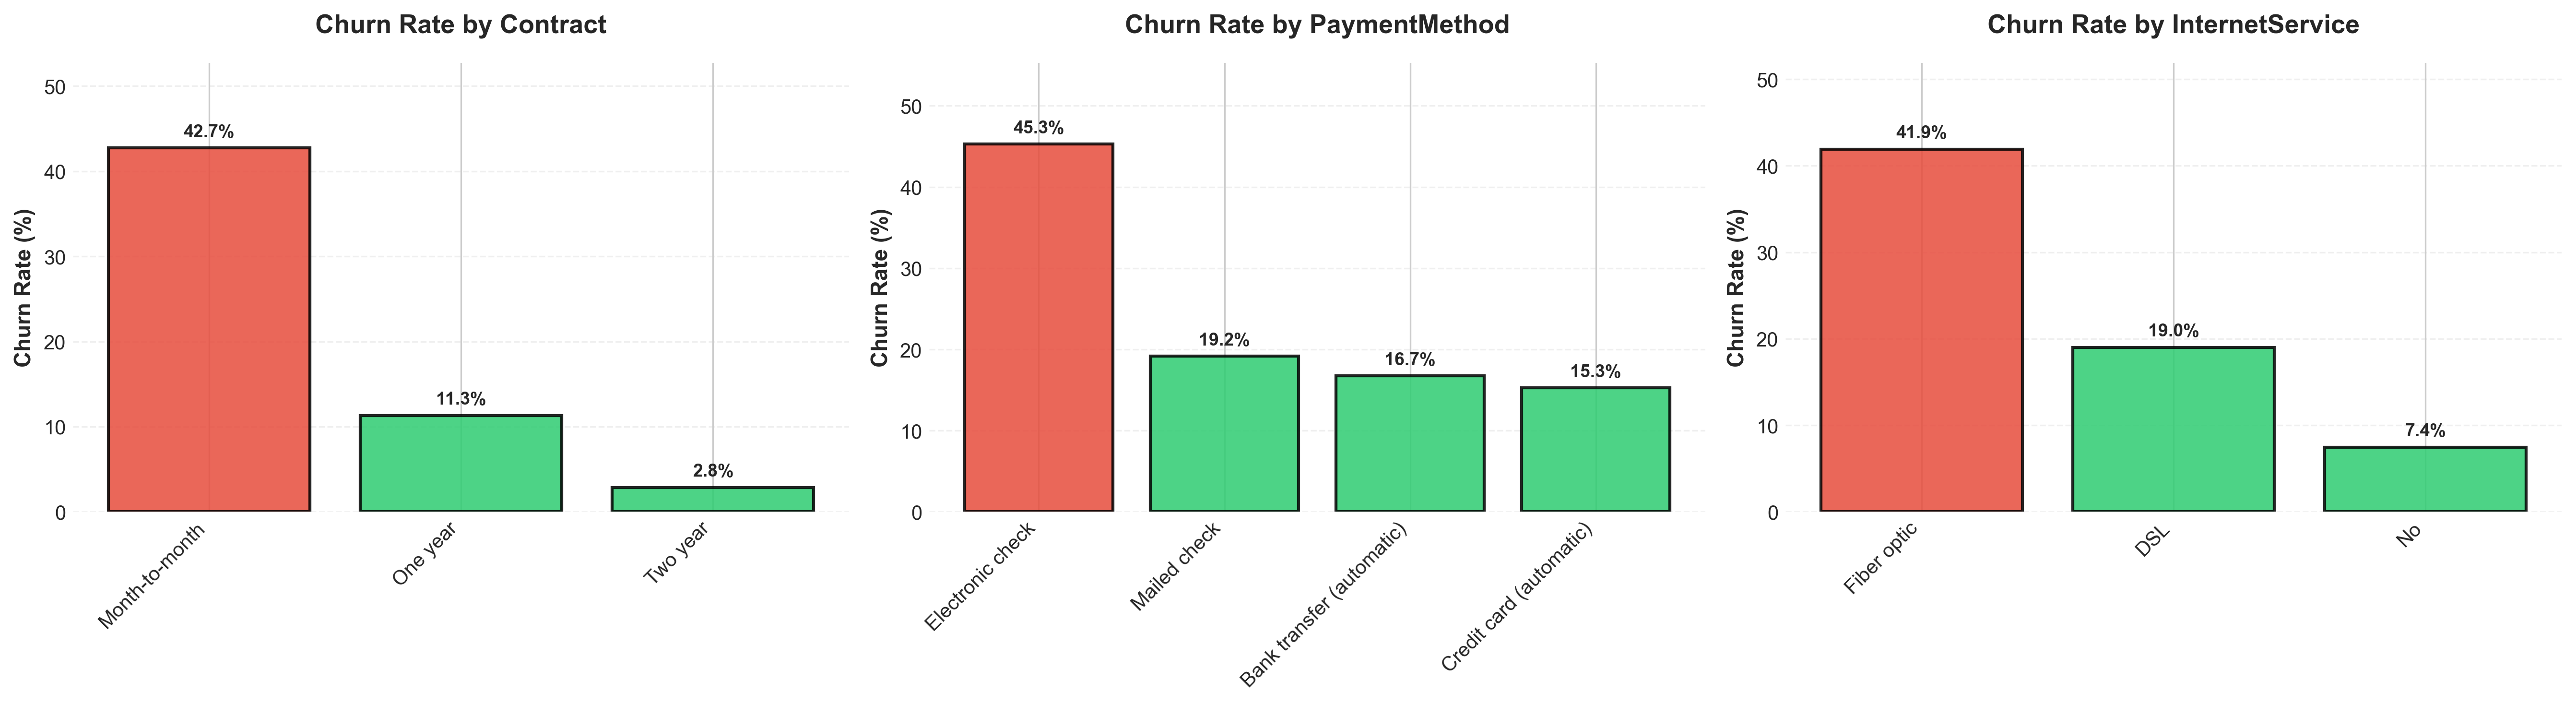


████████████████████████████████████████████████████████████████████████████████
█                     CATEGORICAL FEATURES CHURN ANALYSIS                      █
████████████████████████████████████████████████████████████████████████████████

📊 CONTRACT - Churn Rate by Category:
--------------------------------------------------------------------------------
   Month-to-month                 | Churned: 1655 | Total: 3875 | Rate:  42.71% 🔴 HIGH RISK
   One year                       | Churned:  166 | Total: 1472 | Rate:  11.28% 🟢 LOW RISK
   Two year                       | Churned:   48 | Total: 1685 | Rate:   2.85% 🟢 LOW RISK


📊 PAYMENTMETHOD - Churn Rate by Category:
--------------------------------------------------------------------------------
   Electronic check               | Churned: 1071 | Total: 2365 | Rate:  45.29% 🔴 HIGH RISK
   Mailed check                   | Churned:  308 | Total: 1604 | Rate:  19.20% 🟢 LOW RISK
   Bank transfer (automatic)      | Churned:  258 | Tot

In [75]:
# Analyze categorical features: Contract, PaymentMethod, InternetService
categorical_features = ['Contract', 'PaymentMethod', 'InternetService']

# Create subplots for categorical features
fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=300)

for idx, feature in enumerate(categorical_features):
    # Calculate churn rate for each category
    churn_by_category = df.groupby(feature)['Churn'].apply(lambda x: (x == 'Yes').sum() / len(x) * 100).sort_values(ascending=False)
    
    # Create color palette based on churn rate (red for high, green for low)
    colors_category = ['#e74c3c' if val > 30 else '#f39c12' if val > 20 else '#2ecc71' for val in churn_by_category.values]
    
    # Plot bar chart
    bars = axes[idx].bar(range(len(churn_by_category)), churn_by_category.values, 
                          color=colors_category, edgecolor='black', linewidth=1.5, alpha=0.85)
    axes[idx].set_xticks(range(len(churn_by_category)))
    axes[idx].set_xticklabels(churn_by_category.index, rotation=45, ha='right', fontsize=10)
    axes[idx].set_ylabel('Churn Rate (%)', fontsize=11, fontweight='bold')
    axes[idx].set_title(f'Churn Rate by {feature}', fontsize=13, fontweight='bold', pad=15)
    axes[idx].grid(axis='y', alpha=0.3, linestyle='--')
    axes[idx].set_axisbelow(True)
    axes[idx].set_ylim(0, max(churn_by_category.values) + 10)
    
    # Add value labels on bars
    for i, (bar, val) in enumerate(zip(bars, churn_by_category.values)):
        height = bar.get_height()
        axes[idx].text(bar.get_x() + bar.get_width()/2., height + 1,
                       f'{val:.1f}%', ha='center', va='bottom', 
                       fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# Print detailed categorical analysis
print("\n" + "█"*80)
print("█" + " CATEGORICAL FEATURES CHURN ANALYSIS ".center(78) + "█")
print("█"*80)

for feature in categorical_features:
    print(f"\n📊 {feature.upper()} - Churn Rate by Category:")
    print("-" * 80)
    
    # Calculate churn statistics
    churn_stats = df.groupby(feature).agg({
        'Churn': [lambda x: (x == 'Yes').sum(), 'count']
    }).round(2)
    
    churn_stats.columns = ['Churned', 'Total']
    churn_stats['Churn_Rate_%'] = (churn_stats['Churned'] / churn_stats['Total'] * 100).round(2)
    churn_stats['Retained'] = churn_stats['Total'] - churn_stats['Churned']
    churn_stats = churn_stats.sort_values('Churn_Rate_%', ascending=False)
    
    # Print table
    for category, row in churn_stats.iterrows():
        churn_rate = row['Churn_Rate_%']
        risk_level = "🔴 HIGH RISK" if churn_rate > 30 else "🟠 MEDIUM RISK" if churn_rate > 20 else "🟢 LOW RISK"
        print(f"   {category:30s} | Churned: {int(row['Churned']):4d} | Total: {int(row['Total']):4d} | Rate: {churn_rate:6.2f}% {risk_level}")
    
    print()

print("█"*80)
print("🔍 Key Insights:")
print("   • High churn rates (>30%) indicate categories at risk")
print("   • Medium churn rates (20-30%) require attention")
print("   • Low churn rates (<20%) represent stable customer segments")
print("█"*80 + "\n")

## 5. Data Preprocessing
Transforming raw data into a format suitable for machine learning algorithms.
- **Encoding:** Converting categorical variables (e.g., `Gender`, `Contract`) into numeric format using One-Hot Encoding or Label Encoding.
- **Train-Test Split:** Splitting the dataset into training (80%) and testing (20%) sets to evaluate model performance on unseen data.

In [76]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# 1. Preparing Target Variable (y) and Feature Set (X)
# We map 'Yes' to 1 and 'No' to 0 for the target variable 'Churn'
X = df.drop(columns=['Churn'])
y = df['Churn'].map({'Yes': 1, 'No': 0})

# 2. Encoding Categorical Variables (One-Hot Encoding)
X = pd.get_dummies(X, drop_first=True)

# 3. Splitting the Data into Training and Testing Sets
# test_size = 0.2 (20% for testing), random_state for reproducibility
# stratify=y ensures the churn ration is preserved in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Feature Scaling (Standardization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data preparation complete.")
print(f"Training set shape: {X_train_scaled.shape}, Testing set shape: {X_test_scaled.shape}")

Data preparation complete.
Training set shape: (5625, 30), Testing set shape: (1407, 30)


## 6. Baseline Model Building (Logistic Regression)
We train a Logistic Regression model to establish a baseline performance. Logistic Regression is a simple, interpretable algorithm widely used for binary classification tasks like churn prediction.

In [77]:
from sklearn.linear_model import LogisticRegression

# 1. Initializing the Logistic Regression model
baseline_model = LogisticRegression(random_state=42)

# 2. Training the model on the training data (Fit)
baseline_model.fit(X_train_scaled, y_train)

print("Baseline Logistic Regression model trained successfully.")

Baseline Logistic Regression model trained successfully.


## 7. Model Evaluation
Evaluating the model's performance on the unseen test set using key metrics:
- **Accuracy:** Overall correctness.
- **Confusion Matrix:** Breakdown of correct/incorrect predictions.
- **Classification Report:** Precision, Recall, and F1-Score (Crucial for imbalance).


Baseline Model Accuracy: 0.8038

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1033
       Churn       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



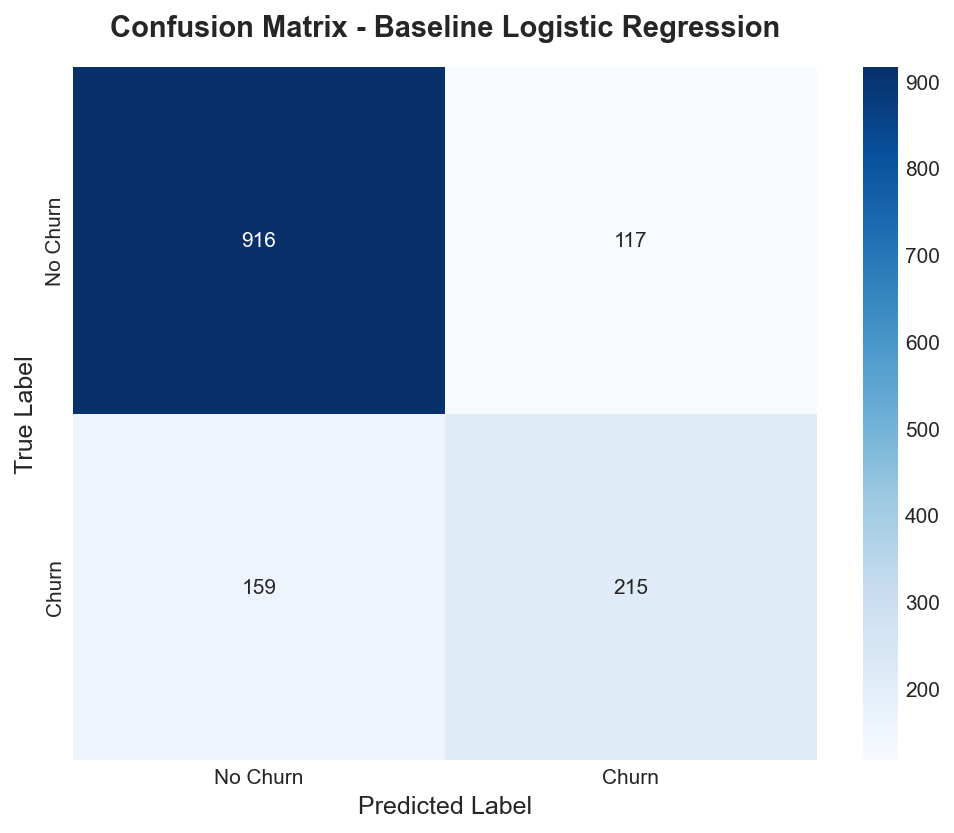

In [78]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Making Predictions on the Test Set
y_pred = baseline_model.predict(X_test_scaled)

# 2. Calculating Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"\nBaseline Model Accuracy: {acc:.4f}")

# 3. Detailed Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

# 4. Visualizing the Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6), dpi=150)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix - Baseline Logistic Regression', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()

In [79]:
# 1. Saving the cleaned dataframe to a new CSV file for future use
df.to_csv('../data/processed/telco_churn_cleaned.csv', index=False)

# 2. Saving the training and testing datasets to separate CSV files
train_data = X_train.copy()
train_data['Churn'] = y_train

test_data = X_test.copy()
test_data['Churn'] = y_test

train_data.to_csv('../data/processed/train_data.csv', index=False)
test_data.to_csv('../data/processed/test_data.csv', index=False)

print("All datasets (cleaned, train, test) saved to 'data/processed/' successfully.")

All datasets (cleaned, train, test) saved to 'data/processed/' successfully.


## 8. Model Serialization
Saving the trained model and the scaler to the `models/` directory using `joblib`. This allows us to load and use the model later without retraining.

In [80]:
import joblib
import os

# Create 'models' directory if it doesn't exist (just in case)
model_dir = '../models'
if not os.path.exists(model_dir):
    os.makedirs(model_dir)

# 1. Save the Logistic Regression Model
joblib.dump(baseline_model, os.path.join(model_dir, 'baseline_model.joblib'))

# 2. Save the Scaler (Crucial for preprocessing new data)
joblib.dump(scaler, os.path.join(model_dir, 'scaler.joblib'))

print(f"Model and Scaler saved successfully in '{model_dir}'")

Model and Scaler saved successfully in '../models'


## 9. Conclusion & Next Steps
- **Performance:** The Logistic Regression baseline achieved an accuracy of **80%**.
- **Critical Issue:** The **Recall for Churn is 0.57**, meaning the model misses 43% of churners. This is likely due to the class imbalance (only 26% churners).
- **Next Steps:** In the Intermediate Phase, we will:
    1. Handle class imbalance using **SMOTE**.
    2. Engineer new features to provide more signal.
    3. Train advanced tree-based models like **Random Forest** and **XGBoost**.;